## Peak performance comparison between Multi-core Scan and `torch.clone` copy operator

> The goal is to understand the "peak performance" of Ascend for a simple element-wise operator like `copy` (copy-in and copy-out). We can use this benchmark as the practical peak performance of Ascend.

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.5
_MARKERS = ["v", "^"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}


In [34]:
# Select plot parameters

# dtype = "int8"
dtype = "fp16"
tiles = [128]

In [35]:
def add_stats_siso(df, nbytes_out_dtype: int):
    # Input number of bytes per element
    df["in_bytes_per_elem"] = df["dtype"].map({"fp16": 2, "int8": 1})

    df["mem_bytes"] = df["size"] * (df["in_bytes_per_elem"] + nbytes_out_dtype)
    
    df["gelemps"] = (df["size"] / 1e9) / (df["time_us"] / 1e6)
    df["bw_gbps"] = ( df["mem_bytes"] / 1e9) / (df["time_us"] / 1e6)

In [36]:
df_baseline = pd.read_csv(f"../../../bench_results_copy_{dtype}.csv")
df_baseline["S"] = "copy"
add_stats_siso(df_baseline, 2)


df_tiled = pd.DataFrame()
for tile in tiles:
    df_tmp = pd.concat(map(pd.read_csv, glob(join('../../..', f"bench_results_mcscan*_{tile}_{dtype}.csv"))))
    df_tmp["S"] = df_tmp["operator"]
    df_tiled = pd.concat([df_tiled, df_tmp])

add_stats_siso(df_tiled, 4)

df = pd.concat([df_tiled])

## Paper plots

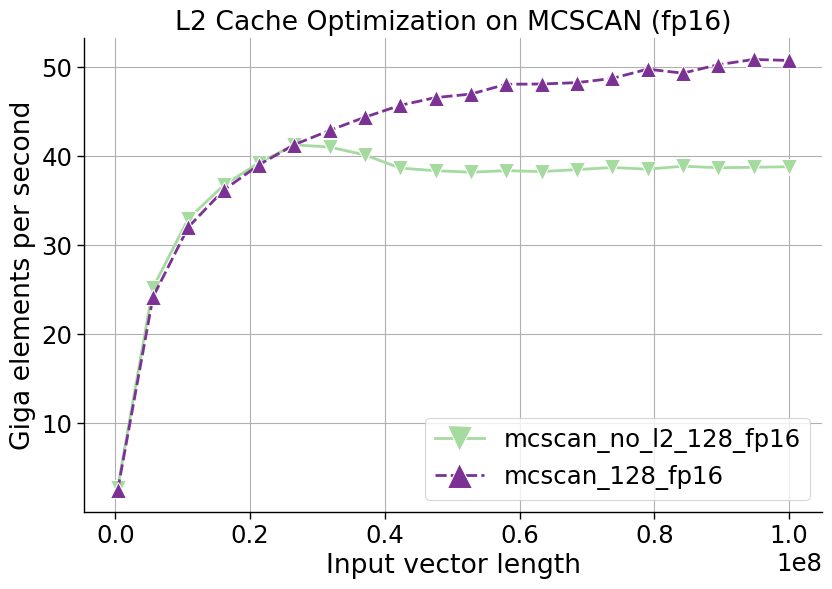

<Figure size 870x627 with 0 Axes>

In [37]:
palette = [### Colorbrewer colors
"#a6dba0",
"#7b3294"]

ax = sns.lineplot(data=df, x='size', y='gelemps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"L2 Cache Optimization on MCSCAN ({dtype})")
ax.set_xlabel("Input vector length")
ax.set_ylabel("Giga elements per second")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()
plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_l2_vs_no_l2_gelemsps_{dtype}.png")
plt.show()
plt.clf()

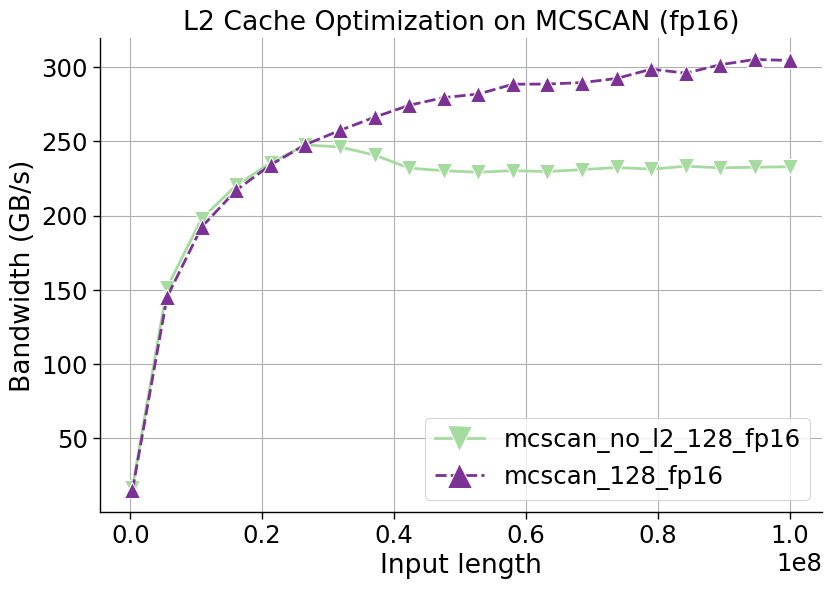

<Figure size 870x627 with 0 Axes>

In [38]:
palette = [### Colorbrewer colors
"#a6dba0",
"#7b3294"]

ax = sns.lineplot(data=df, x='size', y='bw_gbps', palette=palette, **_SNS_PARAMS)

ax.set_title(f"L2 Cache Optimization on MCSCAN ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth (GB/s)")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"figs/mcscan_l2_vs_no_l2_bw_{dtype}.png")
plt.show()
plt.clf()


In [7]:
df

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,gelemps,bw_gbps
0,mcscan_no_l2_128,fp16,327680,None,327680,108.95,mcscan_no_l2_128,2,1966080,3.007618,18.045709
1,mcscan_no_l2_128,fp16,5570560,None,5570560,211.46,mcscan_no_l2_128,2,33423360,26.343327,158.059964
2,mcscan_no_l2_128,fp16,10813440,None,10813440,320.91,mcscan_no_l2_128,2,64880640,33.696176,202.177059
3,mcscan_no_l2_128,fp16,16056320,None,16056320,427.30,mcscan_no_l2_128,2,96337920,37.576223,225.457337
4,mcscan_no_l2_128,fp16,21299200,None,21299200,542.94,mcscan_no_l2_128,2,127795200,39.229381,235.376285
5,mcscan_no_l2_128,fp16,26542080,None,26542080,656.36,mcscan_no_l2_128,2,159252480,40.438296,242.629776
6,mcscan_no_l2_128,fp16,31784960,None,31784960,788.43,mcscan_no_l2_128,2,190709760,40.314245,241.885469
7,mcscan_no_l2_128,fp16,37027840,None,37027840,918.67,mcscan_no_l2_128,2,222167040,40.305921,241.835523
8,mcscan_no_l2_128,fp16,42270720,None,42270720,1079.52,mcscan_no_l2_128,2,253624320,39.156959,234.941752
9,mcscan_no_l2_128,fp16,47513600,None,47513600,1213.51,mcscan_no_l2_128,2,285081600,39.153859,234.923157
